In [1]:
# Image Modeling Pipeline (Features Baseline -> EfficientNetB0)
# This notebook focuses on the image part only.
# 1) Train a simple classifier on pre-extracted image features (baseline).
# 2) Train EfficientNetB0 on raw images (transfer learning).
# 3) Use stratified train/validation split.
# 4) Evaluate with Accuracy, F1 score, Confusion Matrix, and Per-class accuracy.

## Preprocessing Stage
Run all cells in this section first (setup, helpers, manifest, clean/crop/resize, and preprocessing splits).

In [2]:
import os
import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

# Optional, for nicer confusion matrix plots
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# TensorFlow for EfficientNet stage
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
    from tensorflow.keras.applications.efficientnet import preprocess_input
    HAS_TF = True
except Exception:
    HAS_TF = False

RANDOM_STATE = 42
TEST_SIZE = 0.2
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8

# EfficientNet tuning controls
BACKBONE_NAME = "B3"  # "B0" or "B3"
USE_CLASS_WEIGHTS = True
WARMUP_EPOCHS = 8
FINE_TUNE_EPOCHS = 12
FINE_TUNE_TRAINABLE_LAYERS = 60

# Update paths if needed
IMAGE_FEATURES_PATH = "image_features.pkl"
IMAGES_DIR = "images"
TABULAR_PATH = "Data Ready for modeling (1).txt"

def resolve_existing_path(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

project_root_guess = "d:/New folder/Marina/تالته ترم تانى/projectdeep"
DATASET_ROOT = resolve_existing_path([
    "food_dataset",
    "./food_dataset",
    f"{project_root_guess}/food_dataset",
])

IMAGE_FEATURES_PATH = resolve_existing_path([
    IMAGE_FEATURES_PATH,
    "./image_features.pkl",
    f"{project_root_guess}/image_features.pkl",
])
IMAGES_DIR = resolve_existing_path([
    "./food_dataset/images_clean_crop_resize",
    f"{project_root_guess}/food_dataset/images_clean_crop_resize",
    IMAGES_DIR,
    "./images",
    "./Images",
    "./food_dataset/images",
    f"{project_root_guess}/images",
    f"{project_root_guess}/Images",
    f"{project_root_guess}/food_dataset/images",
])
TABULAR_PATH = resolve_existing_path([
    TABULAR_PATH,
    "./Data Ready for modeling (1).txt",
    f"{project_root_guess}/Data Ready for modeling (1).txt",
])

# Keep a stable pointer to raw images before creating processed images.
RAW_IMAGES_DIR = resolve_existing_path([
    "./food_dataset/images",
    f"{project_root_guess}/food_dataset/images",
    IMAGES_DIR,
])

print("DATASET_ROOT:", DATASET_ROOT)
print("IMAGE_FEATURES_PATH:", IMAGE_FEATURES_PATH)
print("RAW_IMAGES_DIR:", RAW_IMAGES_DIR)
print("IMAGES_DIR:", IMAGES_DIR)
print("TABULAR_PATH:", TABULAR_PATH)
print("BACKBONE_NAME:", BACKBONE_NAME)
print("TensorFlow available:", HAS_TF)

DATASET_ROOT: d:/New folder/Marina/تالته ترم تانى/projectdeep/food_dataset
IMAGE_FEATURES_PATH: d:/New folder/Marina/تالته ترم تانى/projectdeep/image_features.pkl
RAW_IMAGES_DIR: d:/New folder/Marina/تالته ترم تانى/projectdeep/food_dataset/images
IMAGES_DIR: d:/New folder/Marina/تالته ترم تانى/projectdeep/food_dataset/images_clean_crop_resize
TABULAR_PATH: d:/New folder/Marina/تالته ترم تانى/projectdeep/Data Ready for modeling (1).txt
TensorFlow available: True


In [ ]:
def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def infer_keyword_from_filename(file_name, keyword_set):
    stem = Path(str(file_name)).stem.lower()
    txt = re.sub(r"[_\-\.]+", " ", stem)
    # Try direct keyword match
    for kw in sorted(keyword_set, key=len, reverse=True):
        if re.search(rf"\b{re.escape(kw)}\b", txt):
            return kw
    # Fallback to first token
    first = txt.split()[0] if txt.split() else ""
    return first

def show_confusion(y_true, y_pred, labels, title, normalize=True):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_plot = cm / row_sums
    else:
        cm_plot = cm

    plt.figure(figsize=(12, 10))
    if HAS_SEABORN:
        sns.heatmap(
            cm_plot,
            annot=False,
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            vmin=0,
            vmax=1 if normalize else None,
        )
    else:
        plt.imshow(cm_plot, cmap="Blues", vmin=0, vmax=1 if normalize else None)
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
        plt.colorbar()
    suffix = " (Normalized)" if normalize else ""
    plt.title(title + suffix)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def per_class_accuracy(y_true, y_pred):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    out = []
    for c, g in df.groupby("y_true"):
        acc = (g["y_true"] == g["y_pred"]).mean()
        out.append({"class": c, "per_class_accuracy": float(acc), "count": int(len(g))})
    return pd.DataFrame(out).sort_values("per_class_accuracy", ascending=False).reset_index(drop=True)

## Image Data Preparation
This step builds a clean image manifest before training any model.
It links the product file, image URLs, local image paths, and keyword labels into one training table.

In [4]:
# -----------------------------
# Image Manifest Preparation
# -----------------------------
def resolve_existing_path(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

def build_image_manifest(product_file_path, images_dir=None):
    """
    Build a unified manifest for image training.
    Supports product files with remote image URLs and/or local image paths.
    """
    prod_df = pd.read_csv(product_file_path)
    prod_df.columns = [c.strip() for c in prod_df.columns]

    # Normalize common column names
    rename_map = {}
    for col in prod_df.columns:
        low = col.lower().strip()
        if low in {"product name", "product_name", "name"}:
            rename_map[col] = "product_name"
        elif low in {"imgurl", "image_url", "imageurl", "image url", "img_url"}:
            rename_map[col] = "img_url"
        elif low in {"url", "product_url", "product url", "page_url"}:
            rename_map[col] = "product_url"
        elif low in {"keyword", "label", "class"}:
            rename_map[col] = "keyword"
        elif low in {"local_image", "local image", "image_path", "local_image_path"}:
            rename_map[col] = "local_image"
    prod_df = prod_df.rename(columns=rename_map)

    if "product_name" not in prod_df.columns:
        raise ValueError("Product file must contain a product name column.")
    if "img_url" not in prod_df.columns and "local_image" not in prod_df.columns:
        raise ValueError("Product file must contain img_url or local_image.")

    prod_df["product_name"] = prod_df["product_name"].astype(str)
    prod_df["keyword"] = prod_df.get("keyword", prod_df["product_name"]).astype(str).map(normalize_text)

    if "img_url" in prod_df.columns:
        prod_df["img_url"] = prod_df["img_url"].astype(str)
        prod_df["image_file_name"] = prod_df["img_url"].map(lambda x: Path(str(x)).name)
    else:
        prod_df["img_url"] = None
        prod_df["image_file_name"] = None

    # Try to produce local image paths from local_image column first, then from image_file_name.
    prod_df["local_image_path"] = None
    if "local_image" in prod_df.columns:
        base_root = Path(images_dir).parent if (images_dir and os.path.isdir(images_dir)) else Path(".")
        candidate_paths = prod_df["local_image"].astype(str).map(lambda p: (base_root / p).resolve())
        prod_df["local_image_path"] = candidate_paths.map(lambda p: str(p) if p.exists() else None)

    if images_dir is not None and os.path.isdir(images_dir):
        available_files = {p.name.lower(): str(p) for p in Path(images_dir).rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}}
        needs_fill = prod_df["local_image_path"].isna()
        prod_df.loc[needs_fill, "local_image_path"] = prod_df.loc[needs_fill, "image_file_name"].astype(str).str.lower().map(available_files.get)

    prod_df["has_local_image"] = prod_df["local_image_path"].notna()

    return prod_df

# Optional paths if you have them
PRODUCT_FILE_PATH = resolve_existing_path([
    "food_dataset/products_preprocessed.csv",
    "./food_dataset/products_preprocessed.csv",
    f"{project_root_guess}/food_dataset/products_preprocessed.csv",
    "amazon_grocery_with_images_from_csv.csv",
    "./amazon_grocery_with_images_from_csv.csv",
    f"{project_root_guess}/amazon_grocery_with_images_from_csv.csv",
    "product.csv",
    "products.csv",
    "./product.csv",
    "./products.csv",
])

image_manifest_df = None
if PRODUCT_FILE_PATH is not None:
    image_manifest_df = build_image_manifest(PRODUCT_FILE_PATH, IMAGES_DIR)
    print("Product file:", PRODUCT_FILE_PATH)
    print("Manifest rows:", len(image_manifest_df))
    print("Rows with local images:", int(image_manifest_df["has_local_image"].sum()))
    display(image_manifest_df.head(10))
else:
    print("No product file was found yet. Set PRODUCT_FILE_PATH manually in this cell.")
    print("This cell still defines the manifest builder you can use later.")

Product file: d:/New folder/Marina/تالته ترم تانى/projectdeep/food_dataset/products_preprocessed.csv
Manifest rows: 1425
Rows with local images: 1424


,product_name,keyword,product_url,img_url,local_image,image_exists,image_file_name,local_image_path,has_local_image
0,Juhayna,juhayna,https://www.amazon.eg/-/en/JUHAYNA-Carton-Crea...,https://m.media-amazon.com/images/I/712t3O9xoa...,images/Juhayna_87331e20.jpg,True,712t3O9xoaL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
1,Almarai,almarai,https://www.amazon.eg/-/en/Almarai-plain-milk-...,https://m.media-amazon.com/images/I/71Bvh0sGVW...,images/Almarai_995a9ddf.jpg,True,71Bvh0sGVWL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
2,Almarai,almarai,https://www.amazon.eg/-/en/Almarai-Plain-Full-...,https://m.media-amazon.com/images/I/61Lj8VhEgi...,images/Almarai_9745828a.jpg,True,61Lj8VhEgiL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
3,Lamar,lamar,https://www.amazon.eg/-/en/Lamar-Skimmed-milk-...,https://m.media-amazon.com/images/I/51MRYXUXWV...,images/Lamar_465a91c1.jpg,True,51MRYXUXWVL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
4,Juhayna,juhayna,https://www.amazon.eg/-/en/JUHAYNA-Carton-skim...,https://m.media-amazon.com/images/I/71odovadjj...,images/Juhayna_f67d5932.jpg,True,71odovadjjL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
5,Juhayna,juhayna,https://www.amazon.eg/-/en/JUHAYNA-Carton-Crea...,https://m.media-amazon.com/images/I/81hGtj8LI9...,images/Juhayna_e8e4d91c.jpg,True,81hGtj8LI9L._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
6,Almarai,almarai,https://www.amazon.eg/-/en/Almarai-Milk-Full-F...,https://m.media-amazon.com/images/I/71Z9D+YJi8...,images/Almarai_e395dff1.jpg,True,71Z9D+YJi8L._AC_SL1242_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
7,The Milkman,the_milkman,https://www.amazon.eg/-/en/Milkman-litre-long-...,https://m.media-amazon.com/images/I/61MZNv3NGV...,images/The_Milkman_4b403ecf.jpg,True,61MZNv3NGVL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
8,Lamar,lamar,https://www.amazon.eg/-/en/Lamar-full-cream-mi...,https://m.media-amazon.com/images/I/91XUEAyFck...,images/Lamar_bf9d8cba.jpg,True,91XUEAyFckL._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True
9,Juhayna,juhayna,https://www.amazon.eg/-/en/Juhayna-full-cream-...,https://m.media-amazon.com/images/I/51IRW5Biq+...,images/Juhayna_62d43ca9.jpg,True,51IRW5Biq+L._AC_SL1500_.jpg,D:\New folder\Marina\تالته ترم تانى\projectdee...,True


## Image Cleaning + Crop + Resize
This step creates a processed image folder for modeling:
1. Clean image (fix orientation, convert to RGB, skip corrupted files)
2. Center-crop to square
3. Resize to target size (default 224x224)
The model will then use the processed folder automatically.

In [5]:
# -----------------------------
# Clean Image -> Crop -> Resize
# -----------------------------
from PIL import Image, ImageOps, UnidentifiedImageError

TARGET_IMAGE_SIZE = (224, 224)
OUTPUT_QUALITY = 95
FORCE_REPROCESS = False

source_candidate = RAW_IMAGES_DIR if "RAW_IMAGES_DIR" in globals() else IMAGES_DIR
if source_candidate is None or (not os.path.isdir(source_candidate)):
    raise FileNotFoundError("Images source folder is not set correctly. Please fix setup paths first.")

source_dir = Path(source_candidate)
processed_dir = source_dir.parent / "images_clean_crop_resize"
processed_dir.mkdir(parents=True, exist_ok=True)

valid_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
source_images = [p for p in source_dir.rglob("*") if p.suffix.lower() in valid_exts]
existing_processed = [p for p in processed_dir.rglob("*.jpg")]

def clean_crop_resize_image(src_path, dst_path, target_size=(224, 224)):
    try:
        with Image.open(src_path) as img:
            # Clean: fix EXIF orientation + enforce RGB
            img = ImageOps.exif_transpose(img).convert("RGB")

            w, h = img.size
            if w < 2 or h < 2:
                return False, "too_small"

            # Crop: center crop to square
            side = min(w, h)
            left = (w - side) // 2
            top = (h - side) // 2
            img = img.crop((left, top, left + side, top + side))

            # Resize: high-quality resize for modeling
            img = img.resize(target_size, Image.Resampling.LANCZOS)

            dst_path.parent.mkdir(parents=True, exist_ok=True)
            img.save(dst_path, format="JPEG", quality=OUTPUT_QUALITY, optimize=True)
            return True, "ok"
    except UnidentifiedImageError:
        return False, "corrupt"
    except Exception as e:
        return False, str(e)

ok_count = 0
fail_count = 0
fail_examples = []

if (not FORCE_REPROCESS) and len(existing_processed) >= len(source_images) and len(source_images) > 0:
    ok_count = len(existing_processed)
    print("Using existing processed images (set FORCE_REPROCESS=True to rebuild).")
else:
    for src in source_images:
        rel = src.relative_to(source_dir)
        dst = (processed_dir / rel).with_suffix(".jpg")
        ok, msg = clean_crop_resize_image(src, dst, TARGET_IMAGE_SIZE)
        if ok:
            ok_count += 1
        else:
            fail_count += 1
            if len(fail_examples) < 10:
                fail_examples.append((str(src), msg))

print("[Image Preprocessing Done]")
print("Source images:", len(source_images))
print("Processed OK:", ok_count)
print("Failed:", fail_count)
print("Processed folder:", processed_dir)

if fail_examples:
    print("\nSample failures:")
    for p, reason in fail_examples:
        print("-", p, "=>", reason)

# Use processed images in downstream modeling cells
IMAGES_DIR = str(processed_dir)
print("\nIMAGES_DIR updated to:", IMAGES_DIR)

# Optional: refresh manifest local paths if manifest exists
if "image_manifest_df" in globals() and isinstance(image_manifest_df, pd.DataFrame):
    processed_index = {p.name.lower(): str(p) for p in processed_dir.rglob("*.jpg")}
    if "local_image" in image_manifest_df.columns:
        image_manifest_df["local_image_path"] = image_manifest_df["local_image"].astype(str).map(lambda p: processed_index.get(Path(p).name.lower()))
    elif "image_file_name" in image_manifest_df.columns:
        image_manifest_df["local_image_path"] = image_manifest_df["image_file_name"].astype(str).str.lower().map(processed_index.get)
    image_manifest_df["has_local_image"] = image_manifest_df["local_image_path"].notna()
    print("Manifest rows with processed local images:", int(image_manifest_df["has_local_image"].sum()))

Using existing processed images (set FORCE_REPROCESS=True to rebuild).
[Image Preprocessing Done]
Source images: 4747
Processed OK: 4747
Failed: 0
Processed folder: d:\New folder\Marina\تالته ترم تانى\projectdeep\food_dataset\images_clean_crop_resize

IMAGES_DIR updated to: d:\New folder\Marina\تالته ترم تانى\projectdeep\food_dataset\images_clean_crop_resize
Manifest rows with processed local images: 1424


In [6]:
# -----------------------------
# Part A-1: Preprocess for Baseline (Image Features)
# -----------------------------
if IMAGE_FEATURES_PATH is None:
    raise FileNotFoundError("image_features.pkl not found.")

if TABULAR_PATH is None:
    raise FileNotFoundError("Tabular file not found.")

tab_df = pd.read_csv(TABULAR_PATH)
tab_df["keyword"] = tab_df["keyword"].astype(str).map(normalize_text)
valid_keywords = set(tab_df["keyword"].unique())

with open(IMAGE_FEATURES_PATH, "rb") as f:
    raw = pickle.load(f)

records = []
if isinstance(raw, dict):
    for name, feat in raw.items():
        kw = infer_keyword_from_filename(name, valid_keywords)
        records.append({
            "image_name": str(name),
            "keyword": kw,
            "feature": np.asarray(feat, dtype=float)
        })
elif isinstance(raw, (list, tuple)):
    for i, item in enumerate(raw):
        if isinstance(item, dict):
            name = item.get("image_name", item.get("path", f"img_{i}"))
            feat = item.get("feature", item.get("features", item.get("embedding", None)))
            kw = normalize_text(item.get("keyword", item.get("label", "")))
            if feat is None:
                continue
            if kw not in valid_keywords:
                kw = infer_keyword_from_filename(name, valid_keywords)
            records.append({
                "image_name": str(name),
                "keyword": kw,
                "feature": np.asarray(feat, dtype=float)
            })

feat_df = pd.DataFrame(records)
feat_df = feat_df[feat_df["keyword"].isin(valid_keywords)].copy()

cnt = feat_df["keyword"].value_counts()
keep = cnt[cnt >= 5].index
feat_df = feat_df[feat_df["keyword"].isin(keep)].reset_index(drop=True)

X = np.vstack(feat_df["feature"].values)
y = feat_df["keyword"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("[Baseline Preprocess Done]")
print("Samples:", len(feat_df))
print("Classes:", pd.Series(y).nunique())
print("Train/Val:", X_train.shape, X_val.shape)

[Baseline Preprocess Done]
Samples: 3013
Classes: 25
Train/Val: (2410, 2048) (603, 2048)


In [7]:
# -----------------------------
# Part B-1: Preprocess for EfficientNetB0 (Processed Images Only)
# -----------------------------
RAW_READY = False

processed_images_dir = resolve_existing_path([
    IMAGES_DIR,
    "./food_dataset/images_clean_crop_resize",
    f"{project_root_guess}/food_dataset/images_clean_crop_resize",
])

if (not HAS_TF) or (processed_images_dir is None):
    print("Skipping EfficientNetB0 preprocess.")
    if not HAS_TF:
        print("Reason: TensorFlow is not available.")
    if processed_images_dir is None:
        print("Reason: processed images folder not found. Run clean/crop/resize cell first.")
else:
    IMAGES_DIR = processed_images_dir
    print("Using processed images directory:", IMAGES_DIR)

    img_exts = {".jpg", ".jpeg", ".png", ".webp"}
    image_paths = []
    for p in Path(IMAGES_DIR).rglob("*"):
        if p.suffix.lower() in img_exts:
            image_paths.append(str(p))

    img_df = pd.DataFrame({"image_path": image_paths})
    img_df["image_name"] = img_df["image_path"].map(lambda p: Path(p).name)
    img_df["keyword"] = img_df["image_name"].map(lambda n: infer_keyword_from_filename(n, valid_keywords))
    img_df = img_df[img_df["keyword"].isin(valid_keywords)].copy()

    img_cnt = img_df["keyword"].value_counts()
    img_keep = img_cnt[img_cnt >= 10].index
    img_df = img_df[img_df["keyword"].isin(img_keep)].reset_index(drop=True)

    if len(img_df) == 0:
        print("No usable image files found after keyword mapping/filtering.")
    else:
        train_df, val_df = train_test_split(
            img_df,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=img_df["keyword"]
        )

        label_encoder = LabelEncoder()
        label_encoder.fit(img_df["keyword"])

        train_df = train_df.copy()
        val_df = val_df.copy()
        train_df["label"] = label_encoder.transform(train_df["keyword"])
        val_df["label"] = label_encoder.transform(val_df["keyword"])

        num_classes = len(label_encoder.classes_)
        print("[EfficientNet Preprocess Done]")
        print("Raw image samples:", len(img_df))
        print("Train/Val:", len(train_df), len(val_df))
        print("Classes:", num_classes)

        def load_image_and_label(path, label):
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32)
            img = preprocess_input(img)
            return img, label

        train_ds = tf.data.Dataset.from_tensor_slices((train_df["image_path"].values, train_df["label"].values))
        val_ds = tf.data.Dataset.from_tensor_slices((val_df["image_path"].values, val_df["label"].values))

        train_ds = train_ds.shuffle(2048, seed=RANDOM_STATE).map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
        val_ds = val_ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        RAW_READY = True

Using processed images directory: d:\New folder\Marina\تالته ترم تانى\projectdeep\food_dataset\images_clean_crop_resize
[EfficientNet Preprocess Done]
Raw image samples: 3013
Train/Val: 2410 603
Classes: 25


## Manifest Diagnostics
Quick check for missing local image matches before modeling.

In [8]:
# -----------------------------
# Diagnostics: Missing local image matches
# -----------------------------
if "image_manifest_df" not in globals() or image_manifest_df is None:
    print("image_manifest_df is not available. Run preprocessing cells first.")
else:
    missing_df = image_manifest_df[~image_manifest_df["has_local_image"]].copy()
    print("Total manifest rows:", len(image_manifest_df))
    print("Rows missing local image:", len(missing_df))

    if len(missing_df) > 0:
        cols_to_show = [c for c in ["product_name", "keyword", "local_image", "image_file_name", "img_url"] if c in missing_df.columns]
        display(missing_df[cols_to_show].head(20))

        # Optional auto-fix attempt by matching any processed file that contains product keyword in filename
        if "local_image_path" in image_manifest_df.columns and "keyword" in image_manifest_df.columns:
            processed_lookup = [str(p) for p in Path(IMAGES_DIR).rglob("*.jpg")] if IMAGES_DIR and os.path.isdir(IMAGES_DIR) else []
            fixed = 0
            for idx in missing_df.index:
                kw = str(image_manifest_df.at[idx, "keyword"]).strip().lower()
                if not kw:
                    continue
                candidates = [p for p in processed_lookup if kw in Path(p).name.lower()]
                if len(candidates) == 1:
                    image_manifest_df.at[idx, "local_image_path"] = candidates[0]
                    fixed += 1

            image_manifest_df["has_local_image"] = image_manifest_df["local_image_path"].notna()
            print("Auto-fixed rows:", fixed)
            print("Rows still missing:", int((~image_manifest_df["has_local_image"]).sum()))
    else:
        print("All rows are matched to local images.")

Total manifest rows: 1425
Rows missing local image: 1


,product_name,keyword,local_image,image_file_name,img_url
152,Spicekick Guava Seed Oil 100ml Natural Rich in...,spicekick_guava_seed_oil_100ml_natural_rich_in...,NaN,612Fc3Mz7GL._AC_SL1500_.jpg,https://m.media-amazon.com/images/I/612Fc3Mz7G...


Auto-fixed rows: 0
Rows still missing: 1


In [9]:
# -----------------------------
# Finalize manifest for training
# -----------------------------
if "image_manifest_df" not in globals() or image_manifest_df is None:
    print("image_manifest_df is not available. Run preprocessing cells first.")
else:
    before_n = len(image_manifest_df)
    image_manifest_df = image_manifest_df[image_manifest_df["has_local_image"]].copy().reset_index(drop=True)
    after_n = len(image_manifest_df)
    removed_n = before_n - after_n

    print("Manifest finalized for training.")
    print("Rows before:", before_n)
    print("Rows after:", after_n)
    print("Rows removed (missing images):", removed_n)

Manifest finalized for training.
Rows before: 1425
Rows after: 1424
Rows removed (missing images): 1


## Modeling Stage
Run these cells only after all preprocessing cells above are completed.

[Baseline - Image Features]
Accuracy: 0.7081
F1 (weighted): 0.7044

Classification report:
              precision    recall  f1-score   support

    biscuits       0.58      0.52      0.55        21
       bread       0.80      0.50      0.62         8
      butter       0.77      0.77      0.77        26
      cheese       0.80      0.76      0.78        37
       chips       0.50      0.14      0.22         7
   chocolate       0.60      0.69      0.64        52
      coffee       0.67      0.65      0.66        40
   detergent       0.83      0.83      0.83         6
       flour       0.61      0.62      0.62        32
       honey       0.77      0.78      0.77        46
         jam       0.85      0.92      0.88        25
       juice       0.78      0.85      0.81        33
        milk       0.00      0.00      0.00         3
        nuts       0.65      0.76      0.70        17
         oil       0.70      0.67      0.68        21
       pasta       0.54      0.64      0.58 

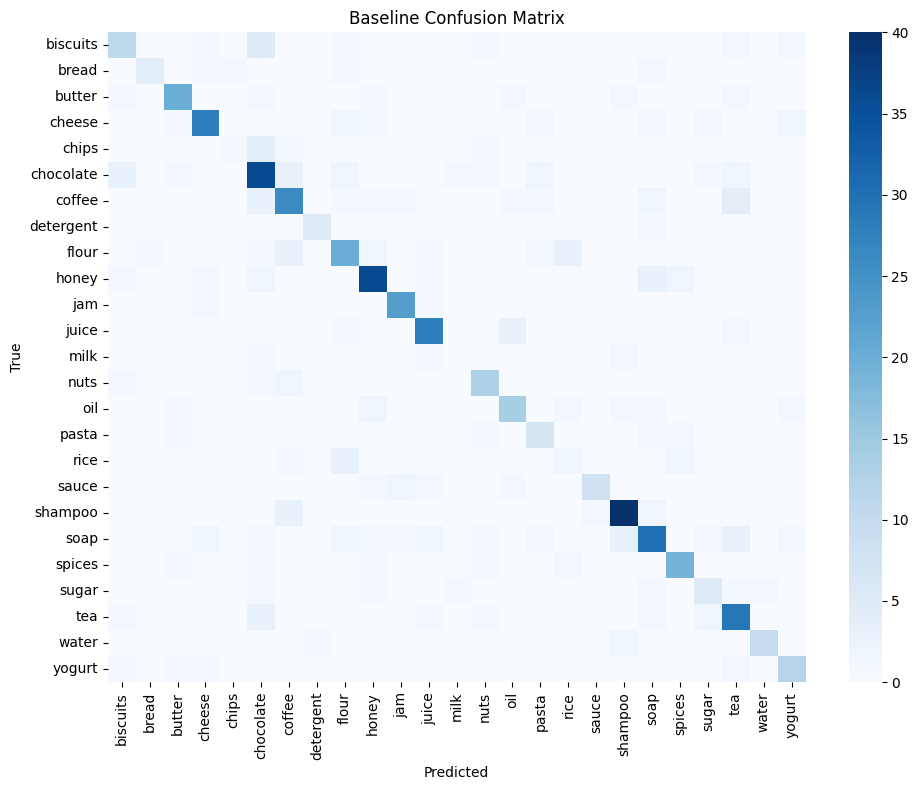

Per-class accuracy (baseline):


,class,per_class_accuracy,count
0,jam,0.920000,25
1,shampoo,0.869565,46
2,juice,0.848485,33
3,detergent,0.833333,6
4,spices,0.791667,24
5,honey,0.782609,46
6,water,0.769231,13
7,butter,0.769231,26
8,nuts,0.764706,17
9,tea,0.763158,38


In [10]:
# -----------------------------
# Part A-2: Baseline Model Training + Evaluation
# -----------------------------
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2500, random_state=RANDOM_STATE, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)
y_val_pred = baseline_model.predict(X_val)

baseline_acc = accuracy_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred, average="weighted")

print("[Baseline - Image Features]")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"F1 (weighted): {baseline_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_val, y_val_pred))

labels_sorted = sorted(pd.Series(y_val).unique())
show_confusion(y_val, y_val_pred, labels_sorted, "Baseline Confusion Matrix")

baseline_per_class = per_class_accuracy(y_val, y_val_pred)
print("Per-class accuracy (baseline):")
display(baseline_per_class.head(20))

Epoch 1/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.2041 - loss: 2.9122 - val_accuracy: 0.4345 - val_loss: 2.3124 - learning_rate: 0.0010
Epoch 2/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.4494 - loss: 2.0969 - val_accuracy: 0.5141 - val_loss: 1.9462 - learning_rate: 0.0010
Epoch 3/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5303 - loss: 1.7439 - val_accuracy: 0.5572 - val_loss: 1.7599 - learning_rate: 0.0010
Epoch 4/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5763 - loss: 1.5509 - val_accuracy: 0.5655 - val_loss: 1.6629 - learning_rate: 0.0010
Epoch 5/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6332 - loss: 1.3921 - val_accuracy: 0.5738 - val_loss: 1.5870 - learning_rate: 0.0010
Epoch 6/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6519 - loss: 1.2766 - val_accuracy: 0.5904 - val_loss: 1.5414 - learning_rate: 0.0010
Epoch 7/8
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 995ms/step - accuracy: 0.6755 - loss: 1.1593 - val_accuracy: 0.6

c:\Users\DCS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DCS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DCS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

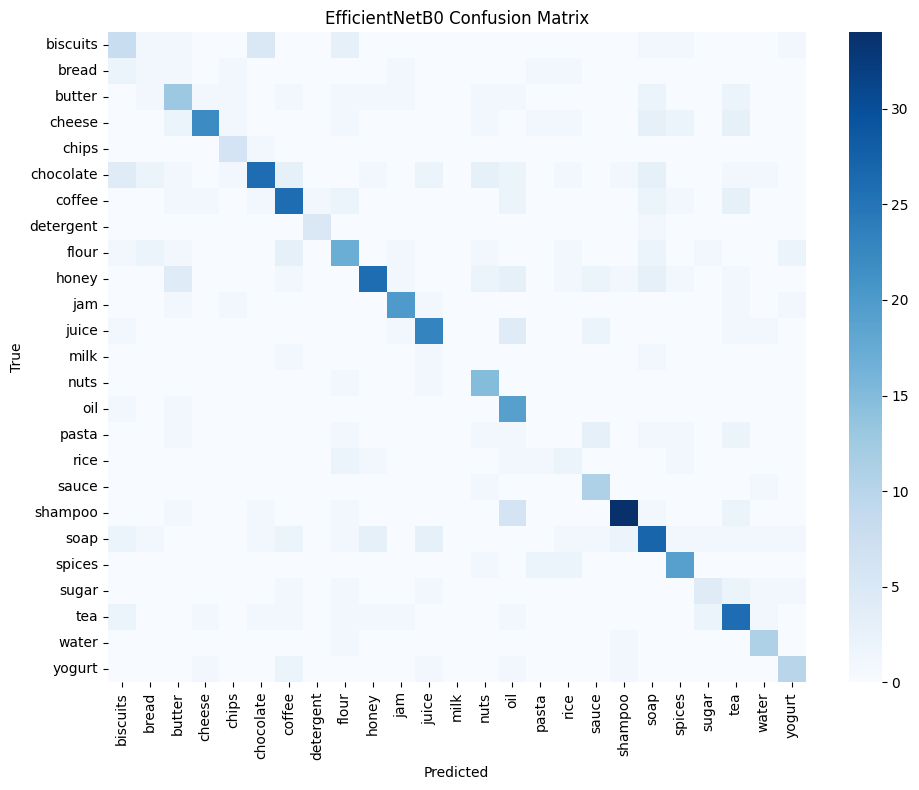

Per-class accuracy (EfficientNetB0):


,class,per_class_accuracy,count
0,oil,0.904762,21
1,nuts,0.882353,17
2,chips,0.857143,7
3,water,0.846154,13
4,sauce,0.846154,13
5,detergent,0.833333,6
6,jam,0.800000,25
7,spices,0.791667,24
8,shampoo,0.739130,46
9,juice,0.696970,33


In [ ]:
# -----------------------------
# Part B-2: EfficientNet Training + Evaluation (Processed Images)
# -----------------------------
if not RAW_READY:
    print("EfficientNet training is skipped because preprocess is not ready.")
else:
    # Class weights to reduce class imbalance effect.
    class_counts = train_df["label"].value_counts().sort_index()
    total_train = len(train_df)
    class_weights = {int(cls): float(total_train / (len(class_counts) * cnt)) for cls, cnt in class_counts.items()}

    data_augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.2),
            layers.RandomTranslation(0.1, 0.1),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.15),
        ],
        name="data_augmentation",
    )

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)

    if str(BACKBONE_NAME).upper() == "B3":
        backbone_cls = EfficientNetB3
    else:
        backbone_cls = EfficientNetB0

    base_model = backbone_cls(include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    eff_model = models.Model(inputs, outputs)

    # Stage 1: train classification head.
    eff_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks_stage1 = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", mode="max", factor=0.5, patience=2, min_lr=1e-6),
    ]

    history_stage1 = eff_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS,
        callbacks=callbacks_stage1,
        class_weight=class_weights if USE_CLASS_WEIGHTS else None,
        verbose=1,
    )

    # Stage 2: fine-tune top layers of backbone.
    base_model.trainable = True
    fine_tune_at = max(1, len(base_model.layers) - int(FINE_TUNE_TRAINABLE_LAYERS))
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    eff_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks_stage2 = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", mode="max", factor=0.5, patience=2, min_lr=1e-7),
    ]

    history_stage2 = eff_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks_stage2,
        class_weight=class_weights if USE_CLASS_WEIGHTS else None,
        verbose=1,
    )

    val_probs = eff_model.predict(val_ds, verbose=0)
    val_pred_labels = np.argmax(val_probs, axis=1)
    val_true_labels = val_df["label"].values
    val_true_keywords = label_encoder.inverse_transform(val_true_labels)
    val_pred_keywords = label_encoder.inverse_transform(val_pred_labels)

    eff_acc = accuracy_score(val_true_keywords, val_pred_keywords)
    eff_f1 = f1_score(val_true_keywords, val_pred_keywords, average="weighted")

    print("\n[EfficientNet - Processed Images]")
    print("Backbone:", BACKBONE_NAME)
    print(f"Accuracy: {eff_acc:.4f}")
    print(f"F1 (weighted): {eff_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(val_true_keywords, val_pred_keywords, zero_division=0))

    eff_labels_sorted = sorted(pd.Series(val_true_keywords).unique())
    show_confusion(val_true_keywords, val_pred_keywords, eff_labels_sorted, "EfficientNet Confusion Matrix", normalize=True)

    eff_per_class = per_class_accuracy(val_true_keywords, val_pred_keywords)
    print("Per-class accuracy (EfficientNet):")
    display(eff_per_class.head(20))